In [1]:
import os
#os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

os.environ['TF_USE_LEGACY_KERAS'] = '1';

In [ ]:
input_default_json_conf_file='fcnn_emotion4_testing_default.json';

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
import datetime
import json

2024-07-24 12:10:38.395709: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-24 12:10:39.812366: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [4]:
import sys
sys.path.append('../library');

In [5]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


2024-07-24 12:10:41.608155: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-07-24 12:10:41.704362: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-07-24 12:10:41.704843: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [6]:
## Load json conf json file
fd = open(os.path.join('./',input_default_json_conf_file));
DATA = json.load(fd);
fd.close()

# Variable globales

In [ ]:
## Seed for the random variables
seed_number=0;

## Dataset 
dataset_base_test_dir    = DATA['dataset_test_base_dir'];
dataset_labels_test_file = DATA['dataset_test_labels_file'];

dataset_name        = DATA['dataset_name'];

## hyperparameters
BATCH_SIZE = DATA["batch_size"];

## Model filepath
best_model_file = DATA['model_file'];

## times to count time
times = DATA['times'];

## Output
output_base_dir = DATA["output_base_dir"];

NCOD=15;

# Parametros de entrada

In [ ]:
for n in range(len(sys.argv)):
    if sys.argv[n]=='--dataset-test-dir':
        dataset_base_test_dir=sys.argv[n+1];
    elif sys.argv[n]=='--dataset-test-file':
        dataset_labels_test_file=sys.argv[n+1];
    elif sys.argv[n]=='--dataset-name':
        dataset_name=sys.argv[n+1];
    elif sys.argv[n]=='--batch-size':
        BATCH_SIZE=int(sys.argv[n+1]);
    elif sys.argv[n]=='--ncod':
        NCOD=int(sys.argv[n+1]);
    elif sys.argv[n]=='--model-file':
        best_model_file=sys.argv[n+1];
    elif sys.argv[n]=='--times':
        times=int(sys.argv[n+1]);
    elif sys.argv[n]=='--output-dir':
        output_base_dir=sys.argv[n+1];
        
print('   dataset_base_test_dir:',dataset_base_test_dir)
print('dataset_labels_test_file:',dataset_labels_test_file)
print('            dataset_name:',dataset_name)
print('              BATCH_SIZE:',BATCH_SIZE)
print('         best_model_file:',best_model_file)
print('                   times:',times)
print('                    NCOD:',NCOD)
print('         output_base_dir:',output_base_dir)

        dataset_base_dir: /media/fernando/Expansion/DATASET/TESE/BER/BER2024/BER2024-SKELETON
     dataset_labels_file: train.csv
   dataset_base_test_dir: /media/fernando/Expansion/DATASET/TESE/BER/BER2024/BER2024-SKELETON
dataset_labels_test_file: test.csv
            dataset_name: ber2024-skel
                  EPOCAS: 40
              BATCH_SIZE: 1024
         output_base_dir: /media/fernando/Expansion/OUTPUTS/DOCTORADO2/fcnn_emotion4


# Set seed of random variables


In [9]:
np.random.seed(seed_number)
tf.keras.utils.set_random_seed(seed_number);

# Loading data of dataset

In [ ]:
# Load test filenames and labels
test_df = pd.read_csv(os.path.join(dataset_base_test_dir,dataset_labels_test_file));

print('\n\ntest_df')
print(test_df)




test_df
              d0         d1        d2         d3         d4        d5  \
0      578.53033  230.53235  0.997254  584.17610  221.87859  0.972028   
1      920.09784  375.53006  0.972105  944.41710  346.81830  0.997568   
2      766.30960  252.15428  0.994588  777.61940  225.52296  0.991696   
3      710.24036  232.16788  0.993728  724.85980  201.97440  0.998824   
4      743.05970  192.98499  0.992488  765.76780  169.78462  0.989598   
...          ...        ...       ...        ...        ...       ...   
16674  439.34560  229.46915  0.991680  457.49250  200.63686  0.990643   
16675  831.20184  257.23987  0.993503  870.40430  225.87146  0.991977   
16676  675.22986  146.00938  0.998339  714.07970  129.44043  0.990368   
16677  365.72820  188.31245  0.993100  383.71097  165.13180  0.991528   
16678  820.39874  276.85623  0.992258  846.90924  255.66278  0.990174   

              d6          d7        d8          d9  ...  d42  d43  d44  d45  \
0      555.77313  209.135130  0.98

# Creating output directory

In [ ]:
output_dir = os.path.join(output_base_dir,dataset_name,'testing_holdout','onlycls_ncod'+str(NCOD));

os.makedirs(output_base_dir,exist_ok = True);

os.makedirs(output_dir,exist_ok = True);

# Data augmentation configuration

In [ ]:
import SkeletonEmotion4Lib.DataAugmentation as sda
import SkeletonEmotion4Lib.lib_tools as slt

test_data_array       = slt.batch_normalize_coordinates(test_df.iloc[:,0:51].values)


test_dataset = sda.DataAugmentationClsGenerator(test_data_array, 
                                                test_df.iloc[:,51].values,
                                                batch_size=BATCH_SIZE, 
                                                augment_fn=None,
                                                shuffle=False);

print('test:',test_data_array.shape)

train: (21594, 51)
val: (5399, 51)
test: (16679, 51)


# Create new model

In [ ]:
import SkeletonEmotion4Lib.lib_model as mpp

model = mpp.create_model_onlycls(load_weights=False,
                                file_of_weight=best_model_file,
                                ncod=NCOD);

print('input_shape',model.input_shape)
print('output_shape',model.output_shape)
print('')

model.summary()

mpp.save_model_parameters(model, os.path.join(output_dir,'parameters_stats.m'));

Loading the weights in: /media/fernando/Expansion/OUTPUTS/DOCTORADO2/fcnn_emotion4/ber2024-skel/training_validation_holdout/model_encoder.h5
Loaded the weights in: /media/fernando/Expansion/OUTPUTS/DOCTORADO2/fcnn_emotion4/ber2024-skel/training_validation_holdout/model_encoder.h5
input_shape (None, 51)
output_shape (None, 4)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 15)                17128     
                                                                 
 dense_5 (Dense)             (None, 91)                1456      
                                                                 
 dense_6 (Dense)             (None, 31)                2852      
                                                                 
 dense_7 (Dense)             (None, 15)                480       
                                                        

# Compile

In [ ]:
# COMPILE NEW MODEL
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['categorical_accuracy'])


# Time

In [ ]:
from pytictoc import TicToc
t = TicToc() 

# Evaluate best model


In [ ]:
L=test_dataset.samples;
print('L:',L);


# Evaluate testing
print('Initializing evaluate, please wait ...')
t.tic();
for m in range(times):
    results = model.evaluate(test_dataset,verbose=1)
t0=t.tocvalue();


results = dict(zip(model.metrics_names,results))
results['block_delayms']=t0*1000.0/(times*L);
results['number_of_parameters']=mpp.get_model_parameters(model);
results['ncod']=NCOD;
print(results,"\n\n");


with open(os.path.join(output_dir,"results_testing.m"), 'w') as f: 
    for key, value in results.items(): 
        f.write('%s=%s;\n' % (key, value));

# final all json
with open(os.path.join(output_dir,"testing_data_results.json"), 'w') as f:
    json.dump(results, f,indent=4);

tf.keras.backend.clear_session()

22/22 [==============================] - 1s 41ms/step - loss: 1.2768 - categorical_accuracy: 0.3858
training {'loss': 1.276790738105774, 'categorical_accuracy': 0.38584792613983154} 


6/6 [==============================] - 0s 5ms/step - loss: 1.2753 - categorical_accuracy: 0.3853
validation {'loss': 1.2753082513809204, 'categorical_accuracy': 0.3852565288543701} 


17/17 [==============================] - 0s 4ms/step - loss: 1.2850 - categorical_accuracy: 0.3723
testing {'loss': 1.2849749326705933, 'categorical_accuracy': 0.37232446670532227} 




17/17 [==============================] - 0s 9ms/step
Categorical accuracy: 0.3723244798848852
{
    "negative": {
        "precision": 0.31037489102005233,
        "recall": 0.08504538939321549,
        "f1-score": 0.13350834427151698,
        "support": 4186.0
    },
    "neutral": {
        "precision": 0.33274816469837215,
        "recall": 0.46602592758158246,
        "f1-score": 0.388268156424581,
        "support": 4474.0
    },
    "pain": {
        "precision": 0.4666666666666667,
        "recall": 0.6296391752577319,
        "f1-score": 0.536039495337356,
        "support": 3880.0
    },
    "positive": {
        "precision": 0.3289506325973704,
        "recall": 0.32036723846339693,
        "f1-score": 0.32460220318237454,
        "support": 4139.0
    },
    "accuracy": 0.3723244798848852,
    "macro avg": {
        "precision": 0.35968508874561533,
        "recall": 0.37526943267398166,
        "f1-score": 0.3456045498039571,
        "support": 16679.0
    },
    "weighted 

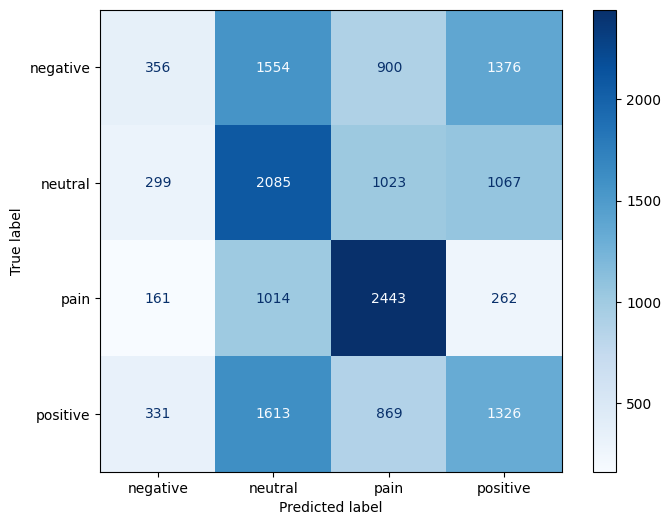

In [27]:
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

target_names = ['negative','neutral','pain','positive'];

# Predict
Y_pred = model.predict(test_dataset,verbose=1);
y_pred = np.argmax(Y_pred, axis=1);

# Calculate accuracy
categorical_accuracy = np.mean(test_dataset.classes == y_pred);
print(f'Categorical accuracy: {categorical_accuracy}');

# Confusion matrix
CM=confusion_matrix(test_dataset.classes, y_pred);

fname=os.path.join(output_dir,"confusion_matrix.eps");
fig, ax = plt.subplots(figsize=(8,6), dpi=100)
disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=target_names)
disp.plot(ax=ax,cmap=plt.cm.Blues)
plt.savefig(fname)

cm_dict=dict();
cm_dict['matrix']=CM.tolist();
cm_dict['label']=target_names;
# final all json
with open(os.path.join(output_dir,"confusion_matrix.json"), 'w') as f:
    json.dump(cm_dict, f,indent=4);
    f.close()

# Classification report
fname=os.path.join(output_dir,"classification_report.json")
dict_dat=classification_report(test_dataset.classes, y_pred, target_names=target_names,output_dict=True);
print(json.dumps(dict_dat, indent=4))
with open(fname, 'w') as f: 
    json.dump(dict_dat, f,indent=4);
    f.close()